### This notebook compute "P12. Distance from the glacier to the lagoon" indicator for the 27 basins of IKI Project

Spanish: Distancia del glaciar a la laguna

**Created:** 6/23/2025 by Jorge Mayo (jmayo@rti.org)  / Serena Gilson

**Project #:** 0219481  

**Last modified:** 1/2/2025 by Sophia (sbakar@rti.org)

**Status:** Completed and value loaded in SQLite database for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\Scripts_Exposure
 
**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib, rasterstats, rasterio

**Further documentation:**  
 
**Inputs:**   MAPA_NACIONAL_DE_ECOSISTEMAS_2012-2018 (MINAM), INAIGEM inventario de glaciares 2020, Peru AHD with districts, 

**Institutions** INAIGEM, MINAM

**Open acess or request data?** Open access from https://geocatmin.ingemmet.gob.pe/geocatmin/ & MINAM
 
**Assumptions:** COMIDs without a glacier are assigned NaN so the indicator is not included in the calculation. 

**Future work:** 
 
**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import rasterio

In [2]:
# set up user and database path
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 112 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define the filepaths for shapefiles and rasters
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
# glaciares = fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\9_GLACIARES\Glaciares_2020_COMID_v2.shp"
glaciares = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\9_GLACIARES\Glaciares_2020_COMID_v2.shp"

In [5]:
# Load the shapefiles
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
glaciares_gdf = gpd.read_file(glaciares).to_crs('EPSG:32718')

<Axes: >

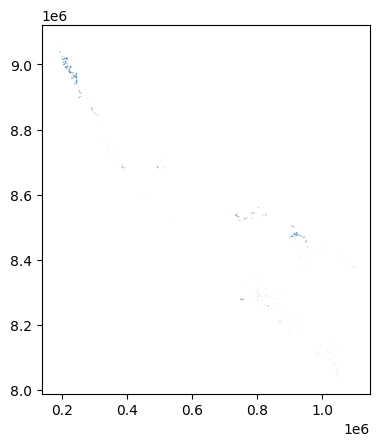

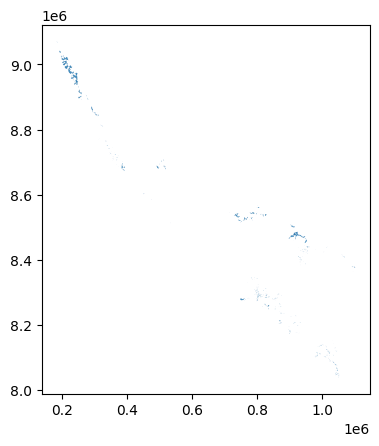

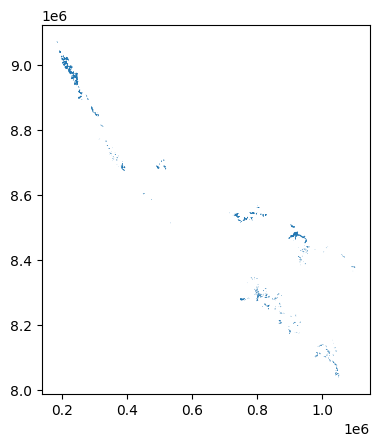

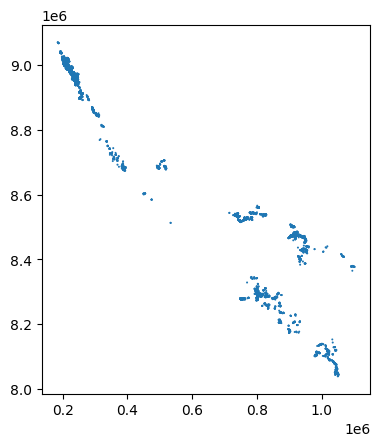

In [6]:
#CALCULATE BUFFERS OF GLACIERS

#Calculate 5m, 100m, 500, and 3000m buffer zones around glaciers
buffer_5m = glaciares_gdf.buffer(5)
buffer_100m = glaciares_gdf.buffer(100)
buffer_500m = glaciares_gdf.buffer(500)
buffer_3000m = glaciares_gdf.buffer(3000)
#Visualize buffer zones
buffer_5m_gdf = gpd.GeoDataFrame(geometry=buffer_5m, crs=glaciares_gdf.crs)
buffer_5m_gdf.plot()
buffer_100m_gdf = gpd.GeoDataFrame(geometry=buffer_100m, crs=glaciares_gdf.crs)
buffer_100m_gdf.plot()  
buffer_500m_gdf = gpd.GeoDataFrame(geometry=buffer_500m, crs=glaciares_gdf.crs)
buffer_500m_gdf.plot()
buffer_3000m_gdf = gpd.GeoDataFrame(geometry=buffer_3000m, crs=glaciares_gdf.crs)
buffer_3000m_gdf.plot()


C:\Users\sbakar\AppData\Local\Temp\ipykernel_51436\3797618925.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.75' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  final_df.loc[(final_df['area_5m'].isnull()) & (final_df['area_100m'].notnull()), 'value'] = 0.75


<Axes: >

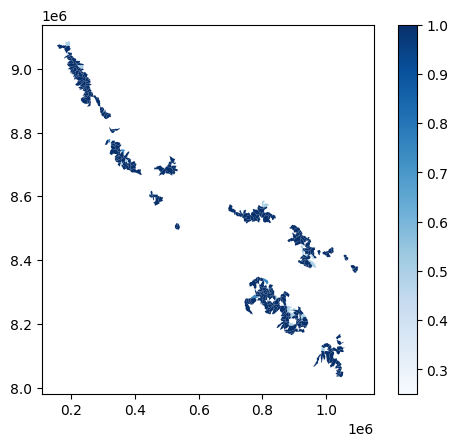

In [7]:
#Intersect buffer zones with subbasins and calculate total area within each subbasin
intersect_5m = gpd.overlay(buffer_5m_gdf, subbasins_gdf, how='intersection')
intersect_100m = gpd.overlay(buffer_100m_gdf, subbasins_gdf, how='intersection')
intersect_500m = gpd.overlay(buffer_500m_gdf, subbasins_gdf, how='intersection')
intersect_3000m = gpd.overlay(buffer_3000m_gdf, subbasins_gdf, how='intersection')

#melt intersected dataframes to have subbasin COMIDs and total areas and combine them into one dataframe with a column for each distance
intersect_5m['area_5m'] = intersect_5m.geometry.area
intersect_100m['area_100m'] = intersect_100m.geometry.area
intersect_500m['area_500m'] = intersect_500m.geometry.area
intersect_3000m['area_3000m'] = intersect_3000m.geometry.area
area_5m_df = intersect_5m.groupby('COMID')['area_5m'].sum().reset_index()
area_100m_df = intersect_100m.groupby('COMID')['area_100m'].sum().reset_index()
area_500m_df = intersect_500m.groupby('COMID')['area_500m'].sum().reset_index()
area_3000m_df = intersect_3000m.groupby('COMID')['area_3000m'].sum().reset_index()
final_df = area_5m_df.merge(area_100m_df, on='COMID', how='outer').merge(area_500m_df, on='COMID', how='outer').merge(area_3000m_df, on='COMID', how='outer')

#if the area_5m has a value, assign a 1 in a new column called value, if the area_100m has a value, assign 0.75, if area_500m has a value, assign 0.5, if area_3000 has a value, assign 0.25. If none of the areas have a value, assign 0
final_df['value'] = 0
final_df.loc[final_df['area_5m'].notnull(), 'value'] = 1
final_df.loc[(final_df['area_5m'].isnull()) & (final_df['area_100m'].notnull()), 'value'] = 0.75
final_df.loc[(final_df['area_5m'].isnull()) & (final_df['area_100m'].isnull()) & (final_df['area_500m'].notnull()), 'value'] = 0.5
final_df.loc[(final_df['area_5m'].isnull()) & (final_df['area_100m'].isnull()) & (final_df['area_500m'].isnull()) & (final_df['area_3000m'].notnull()), 'value'] = 0.25
final_df.loc[(final_df['area_5m'].isnull()) & (final_df['area_100m'].isnull()) & (final_df['area_500m'].isnull()) & (final_df['area_3000m'].isnull()), 'value'] = 0
final_df

#join value column back to subbasins_gdf on COMID to visualize 
subbasins_gdf = subbasins_gdf.merge(final_df[['COMID', 'value']], on='COMID', how='left')
#don't replace NaN values with 0 for those that don't have glaciers
#subbasins_gdf['value'] = subbasins_gdf['value'].fillna(0)
subbasins_gdf.plot(column='value', cmap='Blues', legend=True)


<Axes: >

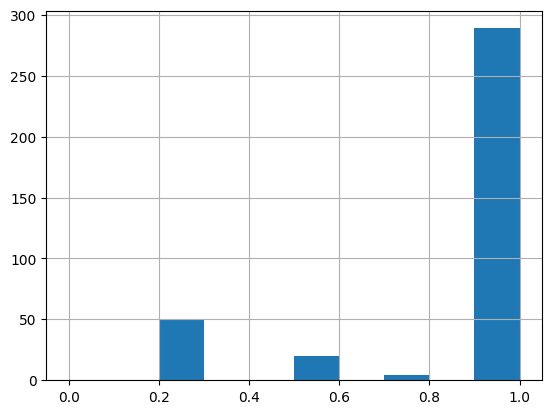

In [8]:
#histogram of values including zero to confirm that those COMIDs without glacier buffer areas have a value of NaN
subbasins_gdf['value'].hist(bins=10, range=(0, 1))

SQLITE INSERT 

In [9]:
insert_data= subbasins_gdf #COMID 
value_column= 'value' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [10]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['value']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 112  Min: 1, Max: 4

=== Values to be inserted (by scenario) ===
   index   value
0    min    0.25
1    max    1.00
2  count  363.00
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [11]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()